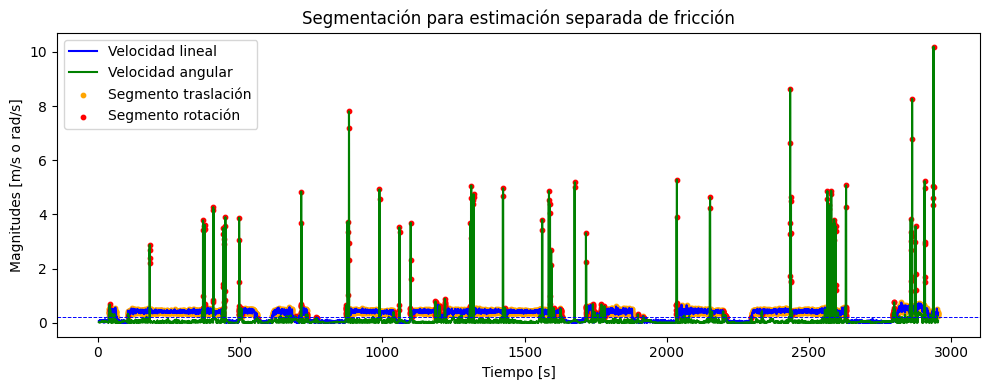


--- Estimación separada ---
mu_x = 1.360727 (traslación en x)
mu_y = 0.805645 (traslación en y)
mu_w = 0.027671 (rotación)


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import least_squares

def extraccion_datos(var, pos):
    home_dir = os.path.expanduser("~")
    ruta_datos = os.path.join(home_dir, "paparazzi", "var", "logs", "25_05_16__11_42_15.data")
    #ruta_datos = os.path.join(home_dir, "paparazzi", "var", "logs", "25_05_16__11_30_21.data")
    dato = []
    tiempo = []
    with open(ruta_datos, "r", encoding="utf-8") as file:
        for line in file:
            if var in line:
                campos = line.strip().split()
                if campos[2] == var:
                    dato.append(float(campos[pos]))
                    tiempo.append(float(campos[0]))
    return np.array(dato), np.array(tiempo)


def filtrado_tiempo_comun(t_comun, dt_min=0.1, dt_max=1):
    dt = np.gradient(t_comun)
    mask = (dt >= dt_min) & (dt <= dt_max)
    mask[0] = True
    indices = np.where(mask)[0]
    t_filtrado = t_comun[indices]
    
    return t_filtrado, indices


def interp_to_common(t_original, data_original, t_comun):
    interp_func = interp1d(t_original, data_original, kind='linear', bounds_error=False, fill_value="extrapolate")
    return interp_func(t_comun)

# --- Extracción de datos ---
escala_vel = 0.0000019
u_raw, t_u = extraccion_datos("INS", 6)
v_raw, t_v = extraccion_datos("INS", 7)
u = u_raw * escala_vel
v = v_raw * escala_vel
orientacion, t_orientacion = extraccion_datos("ATTITUDE", 4)
throttle_L, t_T_L = extraccion_datos("BOAT_CTRL", 7)
throttle_R, t_T_R = extraccion_datos("BOAT_CTRL", 8)
throttle_L_norm = throttle_L / 9600
throttle_R_norm = throttle_R / 9600

masa_barco = 50
distancia_motores = 0.75

# Tiempo común original
t_comun = t_u
t_filtrado, indices_filtrado = filtrado_tiempo_comun(t_comun, dt_min=0.2, dt_max=0.6)

# Interpolación
u_i = interp_to_common(t_u, u, t_filtrado)
v_i = interp_to_common(t_v, v, t_filtrado)
orientacion_i_wrapped = interp_to_common(t_orientacion, orientacion, t_filtrado)
throttle_L_i = interp_to_common(t_T_L, throttle_L_norm, t_filtrado)
throttle_R_i = interp_to_common(t_T_R, throttle_R_norm, t_filtrado)

orientacion_i = np.unwrap(orientacion_i_wrapped)

# Cálculo fuerzas motoras (modelo simplificado)
T_L = (2.4277*(throttle_L_i)**3 + 0.4041*(throttle_L_i)**2 + 0.9662*throttle_L_i - 0.0004)*9.8/masa_barco
T_R = (2.4277*(throttle_R_i)**3 + 0.4041*(throttle_R_i)**2 + 0.9662*throttle_R_i - 0.0004)*9.8/masa_barco
tau_L = -distancia_motores * T_L
tau_R = distancia_motores * T_R
tau = tau_L + tau_R
fa = T_L + T_R

# Derivadas manuales con paso variable
du_manual = np.empty_like(u_i) #Crea array vacio del mismo tamaño que u_i
dv_manual = np.empty_like(v_i) #Crea array vacio del mismo tamaño que v_i
dt = np.diff(t_filtrado) #Calcula el paso de tiempo entre muestras
du_manual[:-1] = np.diff(u_i) / dt #np.diff calcula un array con las diferencias entre los elementos
dv_manual[:-1] = np.diff(v_i) / dt #np.diff calcula un array con las diferencias entre los elementos
du_manual[-1] = du_manual[-2] #El vector de velocidades tendrá 1 elemento menos que el de posiciones (ya que se calcula con las diferencias). En la última pos se repite el antepenultimo valor
dv_manual[-1] = dv_manual[-2] #El vector de velocidades tendrá 1 elemento menos que el de posiciones (ya que se calcula con las diferencias). En la última pos se repite el antepenultimo valor
du = du_manual
dv = dv_manual

dt_medio = np.median(np.diff(t_filtrado))
r = np.gradient(orientacion_i) / dt_medio     # omega
dr = np.gradient(r) / dt_medio                # alpha

inercia_barco = 8 # kg·m²

# --- Estimación separada de coeficientes de fricción ---

# Parámetro de umbral de movimiento total
umbral_parado = 0.2 # Ajusta según tus datos (prueba entre 0.01 y 0.05)

# Magnitudes de movimiento
v_lineal = np.sqrt(u_i**2 + v_i**2)
omega_abs = np.abs(r)

# Cálculo de magnitud total del movimiento
magnitud_total = np.sqrt(v_lineal**2 + omega_abs**2)

# Máscara para excluir zonas con poco movimiento
mask_activo = magnitud_total > umbral_parado

# Segmentación relativa
indices_rot = np.where((omega_abs > v_lineal) & mask_activo)[0]
indices_trans = np.where((v_lineal >= omega_abs) & mask_activo)[0]



# Segmentos de datos para traslación
u_trans = u_i[indices_trans]
v_trans = v_i[indices_trans]
du_trans = du[indices_trans]
dv_trans = dv[indices_trans]
fa_trans = fa[indices_trans]
orientacion_trans = orientacion_i[indices_trans]

# Segmentos de datos para rotación
r_rot = r[indices_rot]
dr_rot = dr[indices_rot]
tau_rot = tau[indices_rot]

# Función de residuos solo para traslación
def residuals_trans(mu):
    mu_x, mu_y = mu
    a = np.cos(orientacion_trans)
    b = np.sin(orientacion_trans)

    term1_x = (a**2)*mu_x*u_trans
    term2_x = (b**2)*mu_y*u_trans
    term3_x = a*b*v_trans*(mu_x - mu_y)
    res_x =  du_trans - (fa_trans * a - (term1_x + term2_x + term3_x))

    term1_y = (b**2)*mu_x*v_trans
    term2_y = (a**2)*mu_y*v_trans
    term3_y = a*b*u_trans*(mu_x - mu_y)
    res_y = dv_trans - (fa_trans * b - (term1_y + term2_y + term3_y))

    return np.concatenate((res_x, res_y))

# Función de residuos solo para rotación
def residuals_rot(mu_w):
    return inercia_barco * dr_rot - (tau_rot - mu_w * r_rot)

# Optimización separada
resultado_trans = least_squares(residuals_trans, [1.0, 1.0])
resultado_rot = least_squares(residuals_rot, 1.0)

mu_x_est, mu_y_est = resultado_trans.x
mu_w_est = resultado_rot.x[0]

# --- Visualización de la segmentación ---
plt.figure(figsize=(10, 4))
plt.plot(t_filtrado, v_lineal, label='Velocidad lineal', color='blue')
plt.plot(t_filtrado, np.abs(r), label='Velocidad angular', color='green')
plt.scatter(t_filtrado[indices_trans], v_lineal[indices_trans], color='orange', label='Segmento traslación', s=10)
plt.scatter(t_filtrado[indices_rot], np.abs(r)[indices_rot], color='red', label='Segmento rotación', s=10)
plt.axhline(umbral_parado, color='blue', linestyle='--', linewidth=0.7)
plt.legend()
plt.xlabel("Tiempo [s]")
plt.ylabel("Magnitudes [m/s o rad/s]")
plt.title("Segmentación para estimación separada de fricción")
plt.tight_layout()
# plt.xlim([500,1000])
# plt.ylim([0,1])
plt.show()

# --- Resultados ---
print("\n--- Estimación separada ---")
print(f"mu_x = {mu_x_est:.6f} (traslación en x)")
print(f"mu_y = {mu_y_est:.6f} (traslación en y)")
print(f"mu_w = {mu_w_est:.6f} (rotación)")
